In [1]:
from inception.instruments import TensorExtensionInterpolator, AutoCallableNoteChebyshev, FullTensorInterpolator
from inception.instruments.constant_parameters import NOTES_PARAMETERS
from inception.instruments import Stock, Portfolio
from inception.instruments.meta_instrument import Greeks
from inception.instruments import ReferenceMultiIndexReturnSimulator, MultiAssetAutoCallableNote

from env.environment import TradingEnv
from tqdm import tqdm
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

import time
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sb
import matplotlib.pyplot as plt

In [2]:
from pandas_datareader import data as pdr

import yfinance as yf
yf.pdr_override() # <== that's all it takes :-)

# download dataframe
data_dia = pdr.get_data_yahoo("DIA", start="2014-01-01", end="2024-03-01")
data_spy = pdr.get_data_yahoo("SPY", start="2014-01-01", end="2024-03-01")
data_xlv = pdr.get_data_yahoo("XLV", start="2014-01-01", end="2024-03-01")

log_return = np.c_[np.diff(np.log(data_dia.Close)), np.diff(np.log(data_spy.Close)), np.diff(np.log(data_xlv.Close))]
log_df = pd.DataFrame(log_return)
corr_matrix = np.corrcoef(log_df.T)
corr_matrix

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


array([[1.        , 0.95951808, 0.82093145],
       [0.95951808, 1.        , 0.83370277],
       [0.82093145, 0.83370277, 1.        ]])

In [3]:
stock_price=[340.82, 494.08, 142.86]
evaluate_date='2024-02-14'

start_date = '2024-02-14'
issued_price = [382.82, 494.08, 142.86]
stock_mean = [0, 0, 0]
index_vol = [0.16, 0.16, 0.16]
risk_free_rate = 0.05
stock_name = ['A', 'B', 'C']

## Tensor Extension

In [4]:
notes_database = './autocallable_database/'
interpolator = TensorExtensionInterpolator(notes_database)
parameters = NOTES_PARAMETERS['CIBC Multi Assets One']

notes_c = AutoCallableNoteChebyshev(start_date=start_date,
                                    evaluate_date=evaluate_date,
                                    underlying_names=stock_name,
                                    stock_price=stock_price,
                                    vol=index_vol,
                                    issue_price=issued_price,
                                    note_interpolator=interpolator,
                                    valuation_dates=parameters['valuation dates'],
                                    call_dates=parameters['call dates'],
                                    coupon_payment_dates=parameters['coupon dates'],
                                    coupon_barrier=parameters['coupon barrier'],
                                    call_barrier=parameters['call barrier'],
                                    principal_barrier=parameters['principal barrier'],
                                    coupon_amount=parameters['coupon amount'],
                                    free_rate=risk_free_rate,
                                    volume=1)

t1 = time.time()
print('Value :', notes_c.value)
print('Delta :', notes_c.delta)
print('Gamma :', notes_c.gamma)
print(f'Total time: {time.time() - t1}')

Value : 101.35490276384944
Delta : A: 0.05488692666155989, B: 0.002753960754905525, C: 0.025255421736284586
Gamma : A: -0.003655510503052242, B: 2.9019348939854046e-05, C: -0.001628453490403703
Total time: 0.04920625686645508


In [5]:
corr_matrix = np.array(
    [[1.        , 0.96432854, 0.80799003],
    [0.96432854, 1.        , 0.8267037 ],
    [0.80799003, 0.8267037 , 1.        ]]
)

path_num = 100_000
d_s = 0.02
simulator = ReferenceMultiIndexReturnSimulator(issued_price, stock_price, risk_free_rate, index_vol, corr_matrix, d_s)
notes = MultiAssetAutoCallableNote(evaluate_date,
                                   ['A', 'B', 'C'],
                                   simulator, 
                                   parameters['valuation dates'],
                                   parameters['coupon dates'],
                                   parameters['call dates'],
                                   coupon_barrier=parameters['coupon barrier'],
                                   call_barrier=parameters['call barrier'],
                                   principal_barrier=parameters['principal barrier'],
                                   coupon_amount=parameters['coupon amount'],
                                   free_rate=risk_free_rate,
                                   n_paths=path_num)
t1 = time.time()
print('Value :', notes.value)
print('Delta :', notes.delta)
print('Gamma :', notes.gamma)
print(f'Total time: {time.time() - t1}')

Value : 100.62428052965532
Delta : A: 0.06466873163703166, B: 0.002291149409013347, C: 0.038640449277978516
Gamma : A: -0.002848795142780115, B: -0.0001638690610947686, C: -0.0035235930243664973
Total time: 4.052076578140259


## Full Tension

In [6]:
stock_price=[382.82, 494.08, 142.86]
evaluate_date='2024-03-15'

start_date = '2024-02-14'
issued_price = [382.82, 494.08, 142.86]
stock_mean = [0, 0, 0]
index_vol = [0.16, 0.16, 0.16]
risk_free_rate = 0.05
stock_name = ['A', 'B', 'C']

In [7]:
notes_database = './one_year_chebyshev_database/'
interpolator = FullTensorInterpolator(notes_database)
parameters = NOTES_PARAMETERS['Multi Assets One Year']

notes_c = AutoCallableNoteChebyshev(start_date=start_date,
                                    evaluate_date=evaluate_date,
                                    underlying_names=stock_name,
                                    stock_price=stock_price,
                                    vol=index_vol,
                                    issue_price=issued_price,
                                    note_interpolator=interpolator,
                                    valuation_dates=parameters['valuation dates'],
                                    call_dates=parameters['call dates'],
                                    coupon_payment_dates=parameters['coupon dates'],
                                    coupon_barrier=parameters['coupon barrier'],
                                    call_barrier=parameters['call barrier'],
                                    principal_barrier=parameters['principal barrier'],
                                    coupon_amount=parameters['coupon amount'],
                                    free_rate=risk_free_rate,
                                    volume=1)

t1 = time.time()
print('Value :', notes_c.value)
print('Delta :', notes_c.delta)
print('Gamma :', notes_c.gamma)
print(f'Total time: {time.time() - t1}')

Value : 101.22714768756545
Delta : A: 0.005321678126246462, B: 0.0037395892188071015, C: 0.024861650013849008
Gamma : A: -0.0009598645777312641, B: -0.0005731510321142334, C: -0.004780518255611654
Total time: 0.0


In [8]:
corr_matrix = np.array(
    [[1.        , 0.96432854, 0.80799003],
    [0.96432854, 1.        , 0.8267037 ],
    [0.80799003, 0.8267037 , 1.        ]]
)

path_num = 100_000
d_s = 0.02
simulator = ReferenceMultiIndexReturnSimulator(issued_price, stock_price, risk_free_rate, index_vol, corr_matrix, d_s)
notes = MultiAssetAutoCallableNote(evaluate_date,
                                   ['A', 'B', 'C'],
                                   simulator, 
                                   parameters['valuation dates'],
                                   parameters['coupon dates'],
                                   parameters['call dates'],
                                   coupon_barrier=parameters['coupon barrier'],
                                   call_barrier=parameters['call barrier'],
                                   principal_barrier=parameters['principal barrier'],
                                   coupon_amount=parameters['coupon amount'],
                                   free_rate=risk_free_rate,
                                   n_paths=path_num)
t1 = time.time()
print('Value :', notes.value)
print('Delta :', notes.delta)
print('Gamma :', notes.gamma)
print(f'Total time: {time.time() - t1}')

Value : 101.314015079656
Delta : A: 0.017537315860629725, B: 0.013299676082613331, C: 0.06554617557339469
Gamma : A: -0.001533630565584089, B: -0.0007930599410017011, C: -0.00951281476427906
Total time: 1.5036883354187012


In [9]:
date_range = pd.bdate_range('2024-02-14', '2025-02-14')

issued_price = [382.82, 494.08, 142.86]

price_percentage = np.arange(0.2, 1.2, 0.05)
values_mocax = []
values_func = []
start_date = pd.Timestamp('2024-02-14')
i = 0
for p in tqdm(price_percentage):
    values_mocax.append([])
    values_func.append([])
    for d in date_range:
        notes_c = AutoCallableNoteChebyshev(start_date=start_date,
                                    evaluate_date=d,
                                    underlying_names=stock_name,
                                    stock_price=[price * p for price in issued_price],
                                    vol=index_vol,
                                    issue_price=issued_price,
                                    note_interpolator=interpolator,
                                    valuation_dates=parameters['valuation dates'],
                                    call_dates=parameters['call dates'],
                                    coupon_payment_dates=parameters['coupon dates'],
                                    coupon_barrier=parameters['coupon barrier'],
                                    call_barrier=parameters['call barrier'],
                                    principal_barrier=parameters['principal barrier'],
                                    coupon_amount=parameters['coupon amount'],
                                    free_rate=risk_free_rate,
                                    volume=1)

        x = [price * p for price in issued_price] + [(d - start_date).days]
        
        values_mocax[i].append(notes_c.value)
#         values_func[i].append(autocallable_note_pricer(x))
    i += 1

100%|██████████████████████████████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 55.67it/s]

The 0th variable is 440.2429999999999, and larger than the upper bound 421.10200000000003
The 1th variable is 568.1919999999998, and larger than the upper bound 543.488
The 2th variable is 164.28899999999996, and larger than the upper bound 157.14600000000002
The 0th variable is 440.2429999999999, and larger than the upper bound 421.10200000000003
The 1th variable is 568.1919999999998, and larger than the upper bound 543.488
The 2th variable is 164.28899999999996, and larger than the upper bound 157.14600000000002
The 0th variable is 440.2429999999999, and larger than the upper bound 421.10200000000003
The 1th variable is 568.1919999999998, and larger than the upper bound 543.488
The 2th variable is 164.28899999999996, and larger than the upper bound 157.14600000000002
The 0th variable is 440.2429999999999, and larger than the upper bound 421.10200000000003
The 1th variable is 568.1919999999998, and larger than the upper bound 543.488
The 2th variable is 164.28899999999996, and larger 

C:\Users\TY482JM\AppData\Local\Temp\ipykernel_7292\3600550708.py:5: MatplotlibDeprecationWarning: Auto-removal of overlapping axes is deprecated since 3.6 and will be removed two minor releases later; explicitly call ax.remove() as needed.
  ax = plt.subplot(121, projection='3d')


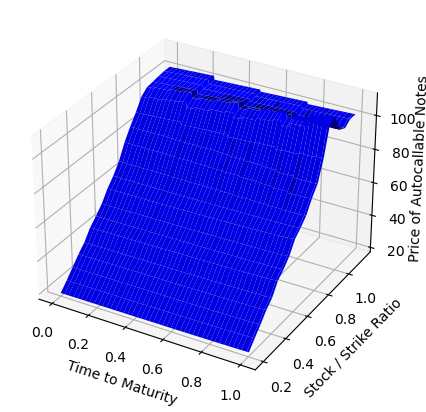

In [10]:
fig = plt.figure(figsize =(15, 5))

plt.subplot(121)
# ax = plt.axes(projection ='3d')
ax = plt.subplot(121, projection='3d')

times = [(d - pd.Timestamp('2024-02-14')).days / 365 for d in date_range]

x1,y1= np.meshgrid(times, price_percentage)

ax.plot_surface(x1, y1, np.array(values_mocax), color='blue')


ax.set_xlabel('Time to Maturity')
ax.set_ylabel('Stock / Strike Ratio')
ax.set_zlabel('Price of Autocallable Notes', rotation=90)
ax.zaxis.labelpad=-0.7

In [13]:
func = lambda x: np.random.uniform(x * 0.2, x * 1.5)
value_m = []
value_p = []
issued_price = [382.82, 494.08, 142.86]
date_range = pd.bdate_range('2024-02-14', '2025-02-14')
start_date = pd.Timestamp('2024-02-14')

for _ in range(1000):
    date = np.random.choice(date_range)
    x = [func(d) for d in issued_price] 
    notes_c = AutoCallableNoteChebyshev(start_date=start_date,
                                        evaluate_date=date,
                                        underlying_names=['A', 'B', 'C'],
                                        stock_price=x,
                                        vol=[0.16, 0.16, 0.16],
                                        issue_price=[382.82, 494.08, 142.86],
                                        note_interpolator=interpolator,
                                        valuation_dates=parameters['valuation dates'],
                                        call_dates=parameters['call dates'],
                                        coupon_payment_dates=parameters['coupon dates'],
                                        coupon_barrier=parameters['coupon barrier'],
                                        call_barrier=parameters['call barrier'],
                                        principal_barrier=parameters['principal barrier'],
                                        coupon_amount=parameters['coupon amount'],
                                        free_rate=0.05)
    simulator = ReferenceMultiIndexReturnSimulator(issued_price, x, risk_free_rate, index_vol, corr_matrix, d_s)
    notes = MultiAssetAutoCallableNote(date,
                                       ['A', 'B', 'C'],
                                       simulator, 
                                       parameters['valuation dates'],
                                       parameters['coupon dates'],
                                       parameters['call dates'],
                                       coupon_barrier=parameters['coupon barrier'],
                                       call_barrier=parameters['call barrier'],
                                       principal_barrier=parameters['principal barrier'],
                                       coupon_amount=parameters['coupon amount'],
                                       free_rate=risk_free_rate,
                                       n_paths=path_num)

    value_m.append(notes_c.value)
    value_p.append(notes.value)

The 1th variable is 554.9778570605383, and larger than the upper bound 543.488
The 2th variable is 168.13357660534444, and larger than the upper bound 157.14600000000002
The 0th variable is 460.4237517923438, and larger than the upper bound 421.10200000000003
The 2th variable is 195.81699468472038, and larger than the upper bound 157.14600000000002
The 1th variable is 689.1028498857869, and larger than the upper bound 543.488
The 1th variable is 606.0975096910277, and larger than the upper bound 543.488
The 1th variable is 640.916708505525, and larger than the upper bound 543.488
The 1th variable is 604.9279754250199, and larger than the upper bound 543.488
The 2th variable is 192.64840535540995, and larger than the upper bound 157.14600000000002
The 0th variable is 464.9498720180963, and larger than the upper bound 421.10200000000003
The 1th variable is 716.8290743593168, and larger than the upper bound 543.488
The 1th variable is 704.121911650585, and larger than the upper bound 543.

The 1th variable is 663.2744155413425, and larger than the upper bound 543.488
The 2th variable is 203.7408590698873, and larger than the upper bound 157.14600000000002
The 0th variable is 485.9542749022717, and larger than the upper bound 421.10200000000003
The 0th variable is 464.2453789541269, and larger than the upper bound 421.10200000000003
The 1th variable is 688.7156485288563, and larger than the upper bound 543.488
The 0th variable is 475.3840283289524, and larger than the upper bound 421.10200000000003
The 2th variable is 202.3456113979092, and larger than the upper bound 157.14600000000002
The 0th variable is 493.7483595592288, and larger than the upper bound 421.10200000000003
The 2th variable is 204.05224199464388, and larger than the upper bound 157.14600000000002
The 2th variable is 202.58777010153233, and larger than the upper bound 157.14600000000002
The 2th variable is 167.22169442214184, and larger than the upper bound 157.14600000000002
The 0th variable is 541.83043

The 2th variable is 191.183602188883, and larger than the upper bound 157.14600000000002
The 2th variable is 203.4353620538745, and larger than the upper bound 157.14600000000002
The 2th variable is 194.87978322816053, and larger than the upper bound 157.14600000000002
The 0th variable is 538.1398917273822, and larger than the upper bound 421.10200000000003
The 2th variable is 190.82756442799814, and larger than the upper bound 157.14600000000002
The 0th variable is 569.6611018493015, and larger than the upper bound 421.10200000000003
The 2th variable is 208.80567653977081, and larger than the upper bound 157.14600000000002
The 1th variable is 614.9354256229534, and larger than the upper bound 543.488
The 2th variable is 188.91535638097778, and larger than the upper bound 157.14600000000002
The 1th variable is 664.3025605083554, and larger than the upper bound 543.488
The 2th variable is 191.5869522111258, and larger than the upper bound 157.14600000000002
The 0th variable is 486.61215

The 0th variable is 572.3331222970088, and larger than the upper bound 421.10200000000003
The 1th variable is 687.4448808348817, and larger than the upper bound 543.488
The 2th variable is 162.81226684134293, and larger than the upper bound 157.14600000000002
The 0th variable is 521.4767180772488, and larger than the upper bound 421.10200000000003
The 1th variable is 728.2987217461704, and larger than the upper bound 543.488
The 0th variable is 492.6923363113046, and larger than the upper bound 421.10200000000003
The 1th variable is 647.3920067641229, and larger than the upper bound 543.488
The 1th variable is 622.133308607351, and larger than the upper bound 543.488
The 2th variable is 181.52332018525738, and larger than the upper bound 157.14600000000002
The 0th variable is 498.53010838600295, and larger than the upper bound 421.10200000000003
The 1th variable is 569.0007483898411, and larger than the upper bound 543.488
The 2th variable is 161.21740246761038, and larger than the upp

The 1th variable is 657.8389889852708, and larger than the upper bound 543.488
The 2th variable is 214.1598283446924, and larger than the upper bound 157.14600000000002
The 0th variable is 518.6502515495774, and larger than the upper bound 421.10200000000003
The 0th variable is 559.5474135906301, and larger than the upper bound 421.10200000000003
The 0th variable is 490.2385179362237, and larger than the upper bound 421.10200000000003
The 1th variable is 686.3994694214896, and larger than the upper bound 543.488
The 0th variable is 558.5662470026673, and larger than the upper bound 421.10200000000003
The 2th variable is 199.2392321228583, and larger than the upper bound 157.14600000000002
The 0th variable is 565.3000145359601, and larger than the upper bound 421.10200000000003
The 2th variable is 184.15876289117952, and larger than the upper bound 157.14600000000002
The 1th variable is 601.5941944372677, and larger than the upper bound 543.488
The 0th variable is 475.2846537304786, and

The 0th variable is 437.7993539887623, and larger than the upper bound 421.10200000000003
The 1th variable is 647.6684322357838, and larger than the upper bound 543.488
The 0th variable is 519.3302061602689, and larger than the upper bound 421.10200000000003
The 2th variable is 173.3556710751798, and larger than the upper bound 157.14600000000002
The 1th variable is 647.2369028474961, and larger than the upper bound 543.488
The 2th variable is 166.32639599159137, and larger than the upper bound 157.14600000000002
The 0th variable is 485.97408359882246, and larger than the upper bound 421.10200000000003
The 0th variable is 505.70199755355486, and larger than the upper bound 421.10200000000003
The 1th variable is 545.86829675911, and larger than the upper bound 543.488
The 0th variable is 542.2405652498003, and larger than the upper bound 421.10200000000003
The 2th variable is 178.09463117698397, and larger than the upper bound 157.14600000000002
The 0th variable is 479.1117729265537, an

The 2th variable is 160.78670951555253, and larger than the upper bound 157.14600000000002
The 0th variable is 529.6515176067293, and larger than the upper bound 421.10200000000003
The 0th variable is 431.11315181247323, and larger than the upper bound 421.10200000000003
The 0th variable is 433.3649858554698, and larger than the upper bound 421.10200000000003
The 1th variable is 600.1076815172207, and larger than the upper bound 543.488
The 1th variable is 591.8619549162138, and larger than the upper bound 543.488
The 0th variable is 485.44247699127243, and larger than the upper bound 421.10200000000003
The 2th variable is 162.44269068468793, and larger than the upper bound 157.14600000000002
The 1th variable is 553.8897075510627, and larger than the upper bound 543.488
The 0th variable is 483.8665456753283, and larger than the upper bound 421.10200000000003
The 2th variable is 181.3878160706531, and larger than the upper bound 157.14600000000002
The 0th variable is 440.57438532966825,

The 0th variable is 530.2163216225629, and larger than the upper bound 421.10200000000003
The 2th variable is 213.158456221751, and larger than the upper bound 157.14600000000002
The 1th variable is 662.51458156298, and larger than the upper bound 543.488
The 2th variable is 206.34760269621762, and larger than the upper bound 157.14600000000002
The 1th variable is 595.3875029977112, and larger than the upper bound 543.488
The 2th variable is 183.5483414645192, and larger than the upper bound 157.14600000000002
The 1th variable is 701.2062299325895, and larger than the upper bound 543.488
The 1th variable is 703.994748085723, and larger than the upper bound 543.488
The 0th variable is 424.73127580643416, and larger than the upper bound 421.10200000000003
The 2th variable is 190.96606744216567, and larger than the upper bound 157.14600000000002
The 1th variable is 704.7024291305099, and larger than the upper bound 543.488
The 2th variable is 166.1077123192801, and larger than the upper b

The 0th variable is 560.4381401238232, and larger than the upper bound 421.10200000000003
The 1th variable is 606.716733494111, and larger than the upper bound 543.488
The 0th variable is 490.5921622319285, and larger than the upper bound 421.10200000000003
The 1th variable is 652.7858660860164, and larger than the upper bound 543.488
The 2th variable is 207.25343646139342, and larger than the upper bound 157.14600000000002
The 2th variable is 182.9929651348909, and larger than the upper bound 157.14600000000002
The 1th variable is 721.1499855096586, and larger than the upper bound 543.488
The 2th variable is 210.35180188499797, and larger than the upper bound 157.14600000000002
The 2th variable is 193.4737943907524, and larger than the upper bound 157.14600000000002
The 2th variable is 165.2315926976613, and larger than the upper bound 157.14600000000002
The 1th variable is 670.4596907879534, and larger than the upper bound 543.488
The 0th variable is 526.1116668047476, and larger tha

The 0th variable is 562.8217078866238, and larger than the upper bound 421.10200000000003
The 0th variable is 443.8130765360059, and larger than the upper bound 421.10200000000003
The 1th variable is 675.9116364593486, and larger than the upper bound 543.488
The 2th variable is 191.305854827042, and larger than the upper bound 157.14600000000002
The 0th variable is 490.34961674290776, and larger than the upper bound 421.10200000000003
The 0th variable is 547.2102336127729, and larger than the upper bound 421.10200000000003
The 2th variable is 196.01686287361701, and larger than the upper bound 157.14600000000002
The 0th variable is 443.68087941735934, and larger than the upper bound 421.10200000000003
The 2th variable is 169.98971400017902, and larger than the upper bound 157.14600000000002
The 1th variable is 619.509093161557, and larger than the upper bound 543.488
The 1th variable is 707.3934162154518, and larger than the upper bound 543.488
The 1th variable is 740.0619382195515, an

Maximum error: 7.02420
Mean error: 0.65162


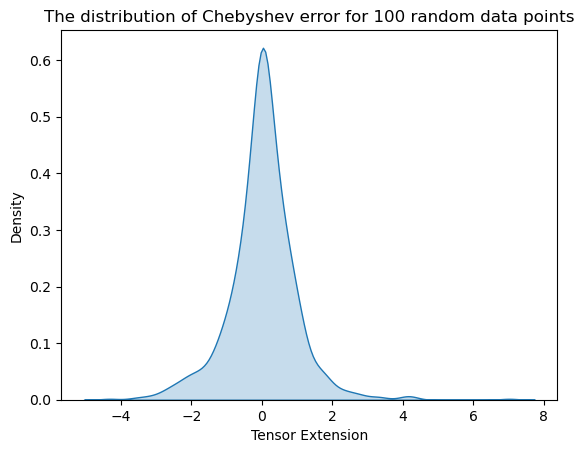

In [14]:
error_2 = (np.array(value_p) - np.array(value_m)) / np.array(value_p) * 100
sb.kdeplot(error_2,fill=True)
plt.title('The distribution of Chebyshev error for 100 random data points')
plt.xlabel('Tensor Extension')

# -- Empirical error
error_sup = max(abs(error_2))
error_mean = abs(error_2).mean()

print(f"Maximum error: {error_sup:.5f}")
print(f"Mean error: {error_mean:.5f}")

In [112]:
from inception.instruments import OptionChebyshevTensor, OptionFullTensorInterpolator
from inception.quantlib_python import VanillaOption
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
import time

In [128]:
interpolator = OptionFullTensorInterpolator('./OptionA_chebyshev_database/', 'Call')
value_m = []
value_p = []

free_rate = 0.05
option_style = 'European'
init_date = '2022-01-01'
t1 = time.time()
for _ in range(1000):
    date = np.random.choice(range(1, 61))
    stock_price = np.random.uniform(100, 600)
    strike = np.random.uniform(100, 600)
    vol = np.random.uniform(0.1, 0.5)

    option = VanillaOption('Call',
                           init_date,
                           exercise_date=date,
                           stock_price=stock_price,
                           strike=strike,
                           vol=vol,
                           free_rate=free_rate,
                           style=option_style)
    option_c = OptionChebyshevTensor('European Call', init_date, date, stock_price, strike, vol, free_rate, interpolator)
    value_m.append(option_c.value)
    value_p.append(option.value)

print(time.time() - t1)

0.5106377601623535


Maximum error: 4.96970
Mean error: 0.01369


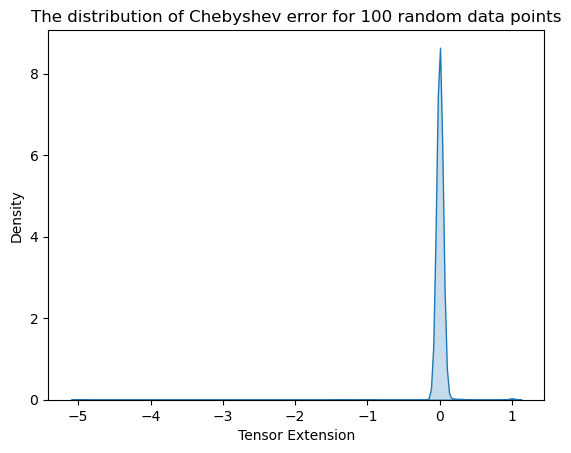

In [130]:
error_2 = [(v - value_m[i]) / v if abs(v) > 0.005 else 0 for i, v in enumerate(value_p)]
sb.kdeplot(error_2,fill=True)
plt.title('The distribution of Chebyshev error for 100 random data points')
plt.xlabel('Tensor Extension')

# -- Empirical error
error_sup = max(np.abs(error_2))
error_mean = np.abs(error_2).mean()

print(f"Maximum error: {error_sup:.5f}")
print(f"Mean error: {error_mean:.5f}")

In [124]:
value_m = []
value_p = []
for s in range(100, 300):
    option = VanillaOption('Call',
                           init_date,
                           exercise_date=1,
                           stock_price=s,
                           strike=150,
                           vol=0.2,
                           free_rate=free_rate,
                           style=option_style)
    option_c = OptionChebyshevTensor('European Call', init_date, 1, s, 150, 0.2, free_rate, interpolator)
    value_m.append(option_c.value)
    value_p.append(option.value)
    


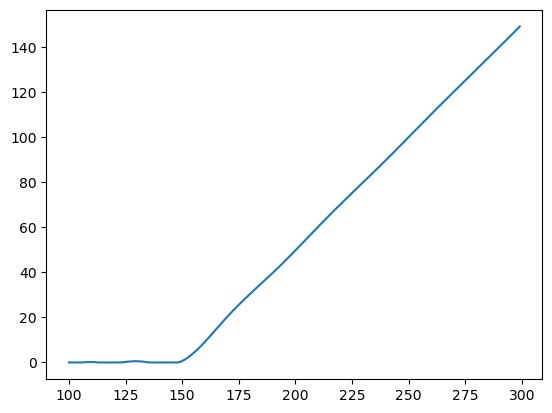

In [127]:
# plt.plot(range(100, 300), value_p)
plt.plot(range(100, 300), value_m)